# Model 1: XGBoost Regressor
**Zindi Urban Air Pollution Challenge — PM2.5 Prediction**

Loads the combined feature table from `01_EDA.ipynb` (`df_combined.parquet`), applies one additional feature exclusion based on a finding made during initial model fitting (see below), then trains and tunes an XGBoost Regressor using the team's shared, location-based `GroupKFold` validation strategy.

See `01_EDA.ipynb` for the full reasoning behind the train/val split strategy.

In [28]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [29]:
df_combined = pd.read_parquet("data/df_combined.parquet")

### Sensor Altitude Feature — Reasoning Summary

- Initial finding: sensor_altitude columns ranked among top features by importance, with moderate target correlation (~-0.31)
- Hypothesis raised: could reflect terrain elevation, which plausibly affects pollutant accumulation (inversion layers, valley/basin effects)
- Verification: value range (~828–844 km) matches Sentinel-5P's known orbital altitude (~824 km), not terrain elevation (max ~8.8 km globally) — confirms this is satellite viewing-geometry metadata, not a ground property
- Risk: likely acts as an indirect proxy for geographic position (latitude/orbit geometry) rather than a causal driver of PM2.5 — no physical mechanism linking satellite altitude to ground-level pollution
- Decision: excluded from final feature set to avoid relying on a non-causal, potentially non-generalizable shortcut
- Future work: true terrain elevation (e.g. DEM/SRTM data) could be a valuable feature if location coordinates become available

In [30]:
drop_metadata = ['L3_AER_AI_sensor_altitude', 'L3_NO2_sensor_altitude', 'L3_CO_sensor_altitude']
df_combined = df_combined.drop(columns=drop_metadata)

In [31]:
train_mask = df_combined.split == 'train'
val_mask = df_combined.split == 'val'
assert set(df_combined.loc[train_mask, 'Place_ID']) & set(df_combined.loc[val_mask, 'Place_ID']) == set()

X_train = df_combined.loc[train_mask].drop(columns=['target', 'split', 'Place_ID', 'Date'])
y_train = df_combined.loc[train_mask, 'target']
groups_train = df_combined.loc[train_mask, 'Place_ID']  # kept separately before Place_ID is dropped above

X_val = df_combined.loc[val_mask].drop(columns=['target', 'split', 'Place_ID', 'Date'])
y_val = df_combined.loc[val_mask, 'target']

## Baseline Model — Dummy Regressor

In [32]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)  # features irrelevant - Dummy ignores X entirely
y_pred = dummy.predict(np.zeros((len(y_val), 1)))

baseline_rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 42.12


## Cross-Validation Sanity Check (Default Hyperparameters)

`GroupKFold` by `Place_ID`, untuned XGBoost — establishes a realistic, leakage-free reference point before spending time on hyperparameter search below.

In [33]:
gkf = GroupKFold(n_splits=5)
fold_scores = []

for train_idx, val_idx in gkf.split(X_train, groups=groups_train):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = XGBRegressor(random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    rmse = mean_squared_error(y_va, model.predict(X_va), squared=False)
    fold_scores.append(rmse)
    print(f"Fold RMSE: {rmse:.3f}")

print(f"\nMean RMSE: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

Fold RMSE: 35.435
Fold RMSE: 35.482
Fold RMSE: 33.926
Fold RMSE: 43.473
Fold RMSE: 31.738

Mean RMSE: 36.011 ± 3.972


## Hyperparameter Tuning (RandomizedSearchCV)

Same `GroupKFold` strategy, now searched over a parameter distribution rather than fixed defaults. `n_iter=100` was chosen after timing a smaller run (~1.5 min for 125 fits) — well within budget for the full search.

In [34]:
param_dist = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),
    'n_estimators': randint(100, 800),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),   # regularization against overfitting on small location groups
    'reg_lambda': uniform(0.5, 4.5)       # L2 regularization, helpful with many correlated satellite features
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=100,
    cv=GroupKFold(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

random_search.fit(X_train, y_train, groups=groups_train)
print(f"Best params: {random_search.best_params_}")
print(f"Best CV RMSE (on 80% train): {-random_search.best_score_:.3f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'colsample_bytree': 0.7390476857930735, 'learning_rate': 0.019223357630697886, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 744, 'reg_lambda': 2.573504456147266, 'subsample': 0.682533487362317}
Best CV RMSE (on 80% train): 33.969


## Final Evaluation on Held-Out Validation Set (20%)

`random_search` refits the best-found estimator on the full 80% train split automatically (`refit=True` is the default) — this evaluates that final model on data it has never seen.

In [ ]:
pred = random_search.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, pred))
print(f"Held-out VAL RMSE (20%): {val_rmse:.2f}")
print(f"Baseline RMSE:           {baseline_rmse:.2f}")
print(f"Improvement over baseline: {100 * (1 - val_rmse / baseline_rmse):.1f}%")

## Feature Importance

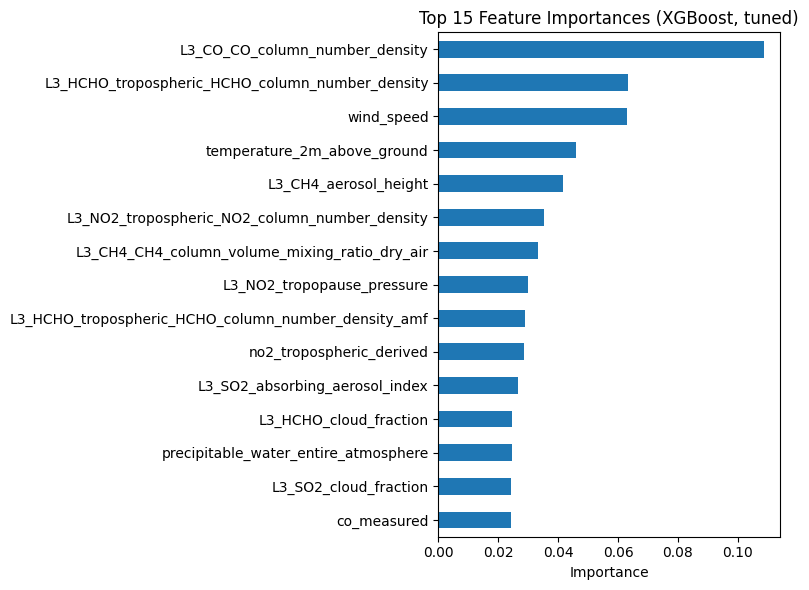

In [36]:
best_model = random_search.best_estimator_  # the actual best model from the search, not refit again

importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost, tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Summary

| Model | Setup | RMSE |
|---|---|---|
| Dummy (mean) | No features | 42.12 |
| XGBoost (default params) | GroupKFold(5) mean | 36.01 ± 3.97 |
| XGBoost (tuned, `RandomizedSearchCV`) | GroupKFold(5) mean, 80% train | 33.97 |
| XGBoost (tuned, final) | Held-out 20% validation | **30.78** |

Key feature-engineering decision carried over from `01_eda.ipynb`: `sensor_altitude` columns were excluded despite ranking highly by importance in an earlier run, since they reflect satellite orbital altitude rather than any causal driver of PM2.5 (see reasoning above).

**Next:** `03_model_randomforest.ipynb` for a comparison model on the same split.